# Preprocesamiento de Datos — Dataset UCI Colelitiasis
## Nicolas Rodriguez Forero & Fabian Rincón Suarez

---

## Índice

1. [Imports y Carga de Datos](#1-imports-y-carga-de-datos)  
2. [Selección de Variables Relevantes](#2-selección-de-variables-relevantes)  
   - 2.1 Justificación clínica y estadística  
   - 2.2 Eliminación de variables redundantes  
3. [Manejo de Valores Atípicos](#3-manejo-de-valores-atípicos)  
4. [Manejo de Valores Faltantes](#4-manejo-de-valores-faltantes)  
5. [Codificación de Variables](#5-codificación-de-variables)  
6. [Escalado de Variables Numéricas](#6-escalado-de-variables-numéricas)  
7. [Validaciones Finales](#7-validaciones-finales)  
8. [Persistencia de Datos Procesados](#8-persistencia-de-datos-procesados)

---

> **Principio fundamental:** Todo ajuste (cálculo de parámetros) se realiza **exclusivamente sobre el conjunto de entrenamiento**. Posteriormente, las mismas transformaciones se aplican al conjunto de prueba, sin recalcular ningún parámetro sobre él. Esto garantiza la ausencia de fuga de datos (*data leakage*).

---

## 1. Imports y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

DOCS_PATH      = Path("../docs")
PROCESSED_PATH = Path("../data/processed")
TARGET         = "Gallstone Status"

DOCS_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

In [2]:
# Cargar particiones crudas guardadas en el notebook de análisis.
# Si los archivos no existen, se rehace el split con el mismo random_state.
raw_train_path = PROCESSED_PATH / "X_train_raw.csv"
raw_test_path  = PROCESSED_PATH / "X_test_raw.csv"

if raw_train_path.exists() and raw_test_path.exists():
    X_train = pd.read_csv(raw_train_path)
    X_test  = pd.read_csv(raw_test_path)
    y_train = pd.read_csv(PROCESSED_PATH / "y_train.csv").squeeze()
    y_test  = pd.read_csv(PROCESSED_PATH / "y_test.csv").squeeze()
    print("Particiones cargadas desde data/processed/")
else:
    df = pd.read_csv("../data/raw/dataset-uci.csv")
    X  = df.drop(columns=[TARGET])
    y  = df[TARGET]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=123, stratify=y
    )
    print("Particiones generadas mediante train_test_split con random_state=123")

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"y_train — clase 0: {(y_train==0).sum()} | clase 1: {(y_train==1).sum()}")

Particiones cargadas desde data/processed/
Train: (255, 38) | Test: (64, 38)
y_train — clase 0: 129 | clase 1: 126


---

## 2. Selección de Variables Relevantes

El dataset contiene 38 variables predictoras. Muchas de ellas provienen de la misma fuente de medición (bioimpedancia) y están altamente correlacionadas entre sí, lo que introduce redundancia y puede perjudicar el rendimiento de modelos sensibles a la multicolinealidad (como la regresión logística o SVM).

La selección se basa en dos criterios:
1. **Relevancia clínica:** se priorizan variables con respaldo en la literatura sobre colelitiasis.
2. **Redundancia estadística:** se eliminan variables que son combinaciones lineales o proxies directos de otras ya incluidas.

### 2.1 Justificación Clínica y Estadística

In [3]:
# Variables a ELIMINAR y justificación
vars_eliminar = {
    "Height":                                     "Representada por BMI junto con Weight",
    "Weight":                                     "Representada por BMI junto con Height",
    "Total Body Water (TBW)":                     "Alta correlación con ECW + ICW; derivado de bioimpedancia",
    "Extracellular Water (ECW)":                  "Componente de TBW; altamente correlacionado con ICW",
    "Intracellular Water (ICW)":                  "Componente de TBW; altamente correlacionado con ECW",
    "Extracellular Fluid/Total Body Water (ECF/TBW)": "Ratio derivado de ECW y TBW",
    "Lean Mass (LM) (%)": "Alta correlación inversa con TBFR; redundante con MM",
    "Muscle Mass (MM)":                           "Alta correlación con Lean Mass y Bone Mass",
    "Bone Mass (BM)":                             "Baja relevancia clínica directa para colelitiasis",
    "Visceral Muscle Area (VMA) (Kg)":            "Alta correlación con VFA; proxy de la misma dimensión",
    "Total Fat Content (TFC)":                    "Alta correlación con TBFR y Obesity (%)",
}

for v, razon in vars_eliminar.items():
    print(f"  - {v:55s} → {razon}")

  - Height                                                  → Representada por BMI junto con Weight
  - Weight                                                  → Representada por BMI junto con Height
  - Total Body Water (TBW)                                  → Alta correlación con ECW + ICW; derivado de bioimpedancia
  - Extracellular Water (ECW)                               → Componente de TBW; altamente correlacionado con ICW
  - Intracellular Water (ICW)                               → Componente de TBW; altamente correlacionado con ECW
  - Extracellular Fluid/Total Body Water (ECF/TBW)          → Ratio derivado de ECW y TBW
  - Lean Mass (LM) (%)                                      → Alta correlación inversa con TBFR; redundante con MM
  - Muscle Mass (MM)                                        → Alta correlación con Lean Mass y Bone Mass
  - Bone Mass (BM)                                          → Baja relevancia clínica directa para colelitiasis
  - Visceral Muscle Area (VMA)

In [4]:
# Variables RETENIDAS
vars_retener = [
    "Age", "Gender",
    "Comorbidity", "Coronary Artery Disease (CAD)",
    "Hypothyroidism", "Hyperlipidemia", "Diabetes Mellitus (DM)",
    "Body Mass Index (BMI)",
    "Total Body Fat Ratio (TBFR) (%)",
    "Body Protein Content (Protein) (%)",
    "Visceral Fat Rating (VFR)",
    "Obesity (%)",
    "Visceral Fat Area (VFA)",
    "Hepatic Fat Accumulation (HFA)",
    "Glucose",
    "Total Cholesterol (TC)",
    "Low Density Lipoprotein (LDL)",
    "High Density Lipoprotein (HDL)",
    "Triglyceride",
    "Aspartat Aminotransferaz (AST)",
    "Alanin Aminotransferaz (ALT)",
    "Alkaline Phosphatase (ALP)",
    "Creatinine",
    "Glomerular Filtration Rate (GFR)",
    "C-Reactive Protein (CRP)",
    "Hemoglobin (HGB)",
    "Vitamin D"
]

print(f"Variables retenidas: {len(vars_retener)}")
print(f"Variables eliminadas: {len(vars_eliminar)}")

Variables retenidas: 27
Variables eliminadas: 11


### 2.2 Eliminación de Variables Redundantes

In [5]:
# Verificar que todas las variables retenidas existen en el dataset
missing_cols = [c for c in vars_retener if c not in X_train.columns]
if missing_cols:
    print(f"ADVERTENCIA — Columnas no encontradas: {missing_cols}")
else:
    print("Todas las variables retenidas existen en el dataset.")

X_train_sel = X_train[vars_retener].copy()
X_test_sel  = X_test[vars_retener].copy()

print(f"\nShape tras selección — Train: {X_train_sel.shape} | Test: {X_test_sel.shape}")

Todas las variables retenidas existen en el dataset.

Shape tras selección — Train: (255, 27) | Test: (64, 27)


---

## 3. Manejo de Valores Atípicos

Se aplica **winsorización** (capping por percentiles 1–99): los valores por debajo del percentil 1 se elevan a ese umbral, y los que superan el percentil 99 se rebajan a él. Los umbrales se calculan **exclusivamente sobre el train** y se aplican también al test.

In [6]:
# Columnas numéricas continuas (excluyendo binarias)
binary_cols = [
    "Gender", "Comorbidity", "Coronary Artery Disease (CAD)",
    "Hypothyroidism", "Hyperlipidemia", "Diabetes Mellitus (DM)"
]
continuous_cols = [c for c in vars_retener if c not in binary_cols]

# Calcular umbrales SOLO sobre train
p01 = X_train_sel[continuous_cols].quantile(0.01)
p99 = X_train_sel[continuous_cols].quantile(0.99)

print("Umbrales de capping (calculados sobre train):")
cap_df = pd.DataFrame({"P01": p01, "P99": p99})
cap_df

Umbrales de capping (calculados sobre train):


,P01,P99
Age,23.0000,76.9200
Body Mass Index (BMI),18.5540,42.9700
Total Body Fat Ratio (TBFR) (%),11.1160,45.1596
Body Protein Content (Protein) (%),9.8276,22.1408
Visceral Fat Rating (VFR),1.0000,22.3000
Obesity (%),1.0540,101.0782
Visceral Fat Area (VFA),2.6700,28.0632
Hepatic Fat Accumulation (HFA),0.0000,3.0000
Glucose,77.1600,347.5400
Total Cholesterol (TC),119.7000,330.0600


In [7]:
# Aplicar capping a train y test usando los mismos umbrales
X_train_cap = X_train_sel.copy()
X_test_cap  = X_test_sel.copy()

for col in continuous_cols:
    X_train_cap[col] = X_train_cap[col].clip(lower=p01[col], upper=p99[col])
    X_test_cap[col]  = X_test_cap[col].clip(lower=p01[col], upper=p99[col])

# Verificación: Obesity (%) post-capping
obesity_col = "Obesity (%)"
print(f"Obesity (%) — Máx train antes: {X_train_sel[obesity_col].max():.1f} "
      f"| Máx train después: {X_train_cap[obesity_col].max():.1f}")
print(f"Obesity (%) — Máx test antes:  {X_test_sel[obesity_col].max():.1f}  "
      f"| Máx test después:  {X_test_cap[obesity_col].max():.1f}")

Obesity (%) — Máx train antes: 1954.0 | Máx train después: 101.1
Obesity (%) — Máx test antes:  95.6  | Máx test después:  95.6


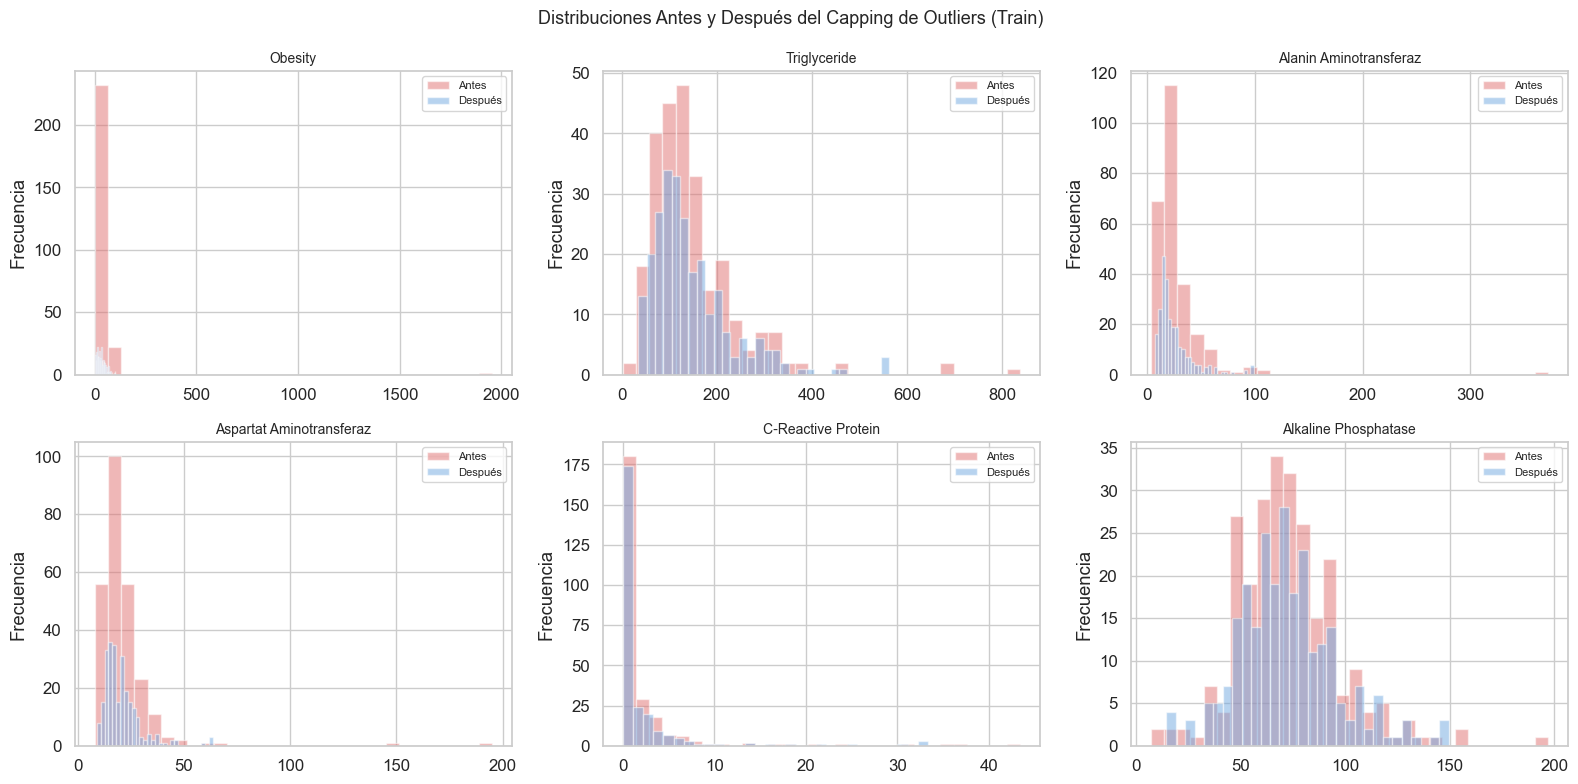

In [8]:
# Visualización comparativa antes/después del capping (variables con outliers extremos)
check_vars = ["Obesity (%)", "Triglyceride", "Alanin Aminotransferaz (ALT)",
              "Aspartat Aminotransferaz (AST)", "C-Reactive Protein (CRP)",
              "Alkaline Phosphatase (ALP)"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(check_vars):
    axes[i].hist(X_train_sel[col].dropna(), bins=30, alpha=0.5,
                 label="Antes", color="#E07070", edgecolor="white")
    axes[i].hist(X_train_cap[col].dropna(), bins=30, alpha=0.5,
                 label="Después", color="#70A8E0", edgecolor="white")
    short = col.split(" (")[0]
    axes[i].set_title(short, fontsize=10)
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend(fontsize=8)

fig.suptitle("Distribuciones Antes y Después del Capping de Outliers (Train)", fontsize=13)
plt.tight_layout()
plt.savefig(DOCS_PATH / "06_capping_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 4. Manejo de Valores Faltantes

Se verifica la presencia de valores faltantes. En caso de existir, se imputa con la **mediana calculada sobre el train** y se aplica la misma mediana al test.

In [9]:
missing_train = X_train_cap.isnull().sum()
missing_test  = X_test_cap.isnull().sum()

if missing_train.any() or missing_test.any():
    print("Valores faltantes en train:")
    print(missing_train[missing_train > 0])
    print("\nValores faltantes en test:")
    print(missing_test[missing_test > 0])

    # Calcular medianas SOLO sobre train
    medianas = X_train_cap[continuous_cols].median()

    X_train_imp = X_train_cap.copy()
    X_test_imp  = X_test_cap.copy()

    for col in continuous_cols:
        X_train_imp[col].fillna(medianas[col], inplace=True)
        X_test_imp[col].fillna(medianas[col], inplace=True)

    print("\nImputación completada con medianas del train.")
else:
    print("No se detectaron valores faltantes. No se requiere imputación.")
    X_train_imp = X_train_cap.copy()
    X_test_imp  = X_test_cap.copy()

No se detectaron valores faltantes. No se requiere imputación.


---

## 5. Codificación de Variables

Todas las variables categóricas del dataset ya están codificadas numéricamente como valores binarios (0/1). Se verifica la consistencia de tipos y que no existan valores inesperados fuera del dominio {0, 1}.

In [10]:
print("Verificación de variables binarias:")
print(f"{'Variable':50s} {'Valores únicos (train)':30s} {'Tipo'}")
print("-" * 90)

for col in binary_cols:
    unique_vals = sorted(X_train_imp[col].unique().tolist())
    dtype = X_train_imp[col].dtype
    status = "OK" if set(unique_vals).issubset({0, 1}) else "REVISAR"
    print(f"{col:50s} {str(unique_vals):30s} {str(dtype):10s} {status}")

Verificación de variables binarias:
Variable                                           Valores únicos (train)         Tipo
------------------------------------------------------------------------------------------
Gender                                             [0, 1]                         int64      OK
Comorbidity                                        [0, 1, 2, 3]                   int64      REVISAR
Coronary Artery Disease (CAD)                      [0, 1]                         int64      OK
Hypothyroidism                                     [0, 1]                         int64      OK
Hyperlipidemia                                     [0, 1]                         int64      OK
Diabetes Mellitus (DM)                             [0, 1]                         int64      OK


In [11]:
# Asegurar tipo int para variables binarias
for col in binary_cols:
    X_train_imp[col] = X_train_imp[col].astype(int)
    X_test_imp[col]  = X_test_imp[col].astype(int)

print("Tipos de dato asignados correctamente.")

Tipos de dato asignados correctamente.


---

## 6. Escalado de Variables Numéricas

Se aplica `StandardScaler` (media 0, desviación estándar 1) sobre las variables continuas. El scaler se **ajusta exclusivamente sobre el train** (`fit`) y luego se **aplica** (`transform`) a ambas particiones por separado. Las variables binarias no se escalan.

In [12]:
scaler = StandardScaler()

# fit SOLO sobre train
scaler.fit(X_train_imp[continuous_cols])

X_train_scaled = X_train_imp.copy()
X_test_scaled  = X_test_imp.copy()

# transform a cada partición por separado
X_train_scaled[continuous_cols] = scaler.transform(X_train_imp[continuous_cols])
X_test_scaled[continuous_cols]  = scaler.transform(X_test_imp[continuous_cols])

print("Escalado aplicado.")
print(f"\nEstadísticas post-escala (train) — se espera media≈0, std≈1:")
stats = X_train_scaled[continuous_cols].agg(["mean", "std"]).T.round(3)
stats.columns = ["Media (train)", "Std (train)"]
stats

Escalado aplicado.

Estadísticas post-escala (train) — se espera media≈0, std≈1:


,Media (train),Std (train)
Age,-0.0,1.002
Body Mass Index (BMI),-0.0,1.002
Total Body Fat Ratio (TBFR) (%),-0.0,1.002
Body Protein Content (Protein) (%),0.0,1.002
Visceral Fat Rating (VFR),-0.0,1.002
Obesity (%),-0.0,1.002
Visceral Fat Area (VFA),0.0,1.002
Hepatic Fat Accumulation (HFA),0.0,1.002
Glucose,-0.0,1.002
Total Cholesterol (TC),0.0,1.002


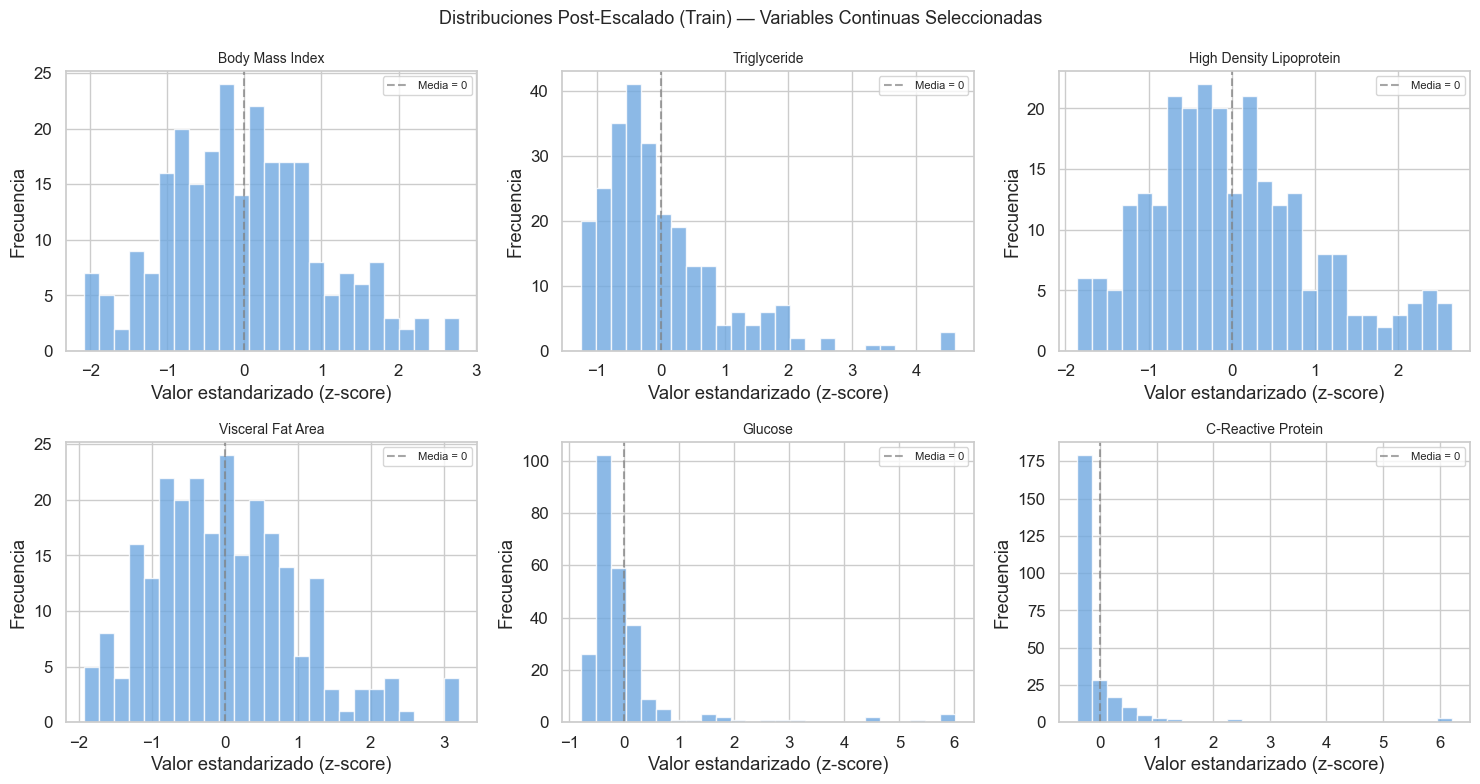

In [13]:
# Visualización: distribuciones post-escala (continuas seleccionadas)
sample_vars = ["Body Mass Index (BMI)", "Triglyceride", "High Density Lipoprotein (HDL)",
               "Visceral Fat Area (VFA)", "Glucose", "C-Reactive Protein (CRP)"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(sample_vars):
    axes[i].hist(X_train_scaled[col], bins=25, color="#70A8E0", edgecolor="white", alpha=0.8)
    axes[i].axvline(0, color="gray", linestyle="--", alpha=0.7, label="Media = 0")
    short = col.split(" (")[0]
    axes[i].set_title(short, fontsize=10)
    axes[i].set_xlabel("Valor estandarizado (z-score)")
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend(fontsize=8)

fig.suptitle("Distribuciones Post-Escalado (Train) — Variables Continuas Seleccionadas", fontsize=13)
plt.tight_layout()
plt.savefig(DOCS_PATH / "07_distribuciones_post_escala.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 7. Validaciones Finales

Antes de persistir los datos, se ejecutan verificaciones que confirman la integridad del preprocesamiento.

In [14]:
print("=" * 55)
print("VALIDACIONES FINALES")
print("=" * 55)

# 1. Shapes
print(f"\n[1] Shapes")
print(f"    X_train: {X_train_scaled.shape} | y_train: {y_train.shape}")
print(f"    X_test:  {X_test_scaled.shape}  | y_test:  {y_test.shape}")
assert X_train_scaled.shape[0] == y_train.shape[0], "Mismatch train"
assert X_test_scaled.shape[0]  == y_test.shape[0],  "Mismatch test"
print("    -> OK")

# 2. Valores faltantes
print(f"\n[2] Valores faltantes")
nan_train = X_train_scaled.isnull().sum().sum()
nan_test  = X_test_scaled.isnull().sum().sum()
print(f"    Train: {nan_train} NaN | Test: {nan_test} NaN")
assert nan_train == 0 and nan_test == 0, "Existen NaN residuales"
print("    -> OK")

# 3. Balance de clases
print(f"\n[3] Balance de clases")
print(f"    Train — clase 0: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%) "
      f"| clase 1: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print(f"    Test  — clase 0: {(y_test==0).sum()}  ({(y_test==0).mean()*100:.1f}%) "
      f"| clase 1: {(y_test==1).sum()}  ({(y_test==1).mean()*100:.1f}%)")
print("    -> OK")

# 4. Variables binarias intactas (solo 0 y 1)
print(f"\n[4] Integridad de variables binarias")
for col in binary_cols:
    train_vals = set(X_train_scaled[col].unique())
    test_vals  = set(X_test_scaled[col].unique())
    ok = train_vals.issubset({0, 1}) and test_vals.issubset({0, 1})
    print(f"    {col:45s} {'OK' if ok else 'REVISAR'}")

# 5. Número de columnas
print(f"\n[5] Columnas")
print(f"    Train: {X_train_scaled.columns.tolist()}")
assert list(X_train_scaled.columns) == list(X_test_scaled.columns), "Columnas no coinciden"
print(f"    -> {X_train_scaled.shape[1]} columnas en ambas particiones. OK")

print("\n" + "=" * 55)
print("Todas las validaciones superadas.")
print("=" * 55)

VALIDACIONES FINALES

[1] Shapes
    X_train: (255, 27) | y_train: (255,)
    X_test:  (64, 27)  | y_test:  (64,)
    -> OK

[2] Valores faltantes
    Train: 0 NaN | Test: 0 NaN
    -> OK

[3] Balance de clases
    Train — clase 0: 129 (50.6%) | clase 1: 126 (49.4%)
    Test  — clase 0: 32  (50.0%) | clase 1: 32  (50.0%)
    -> OK

[4] Integridad de variables binarias
    Gender                                        OK
    Comorbidity                                   REVISAR
    Coronary Artery Disease (CAD)                 OK
    Hypothyroidism                                OK
    Hyperlipidemia                                OK
    Diabetes Mellitus (DM)                        OK

[5] Columnas
    Train: ['Age', 'Gender', 'Comorbidity', 'Coronary Artery Disease (CAD)', 'Hypothyroidism', 'Hyperlipidemia', 'Diabetes Mellitus (DM)', 'Body Mass Index (BMI)', 'Total Body Fat Ratio (TBFR) (%)', 'Body Protein Content (Protein) (%)', 'Visceral Fat Rating (VFR)', 'Obesity (%)', 'Visceral F

---

## 8. Persistencia de Datos Procesados

Se guardan las cuatro particiones procesadas en `data/processed/` para ser consumidas por el notebook de modelos.

In [15]:
X_train_scaled.to_csv(PROCESSED_PATH / "X_train_processed.csv", index=False)
X_test_scaled.to_csv(PROCESSED_PATH  / "X_test_processed.csv",  index=False)
y_train.to_csv(PROCESSED_PATH        / "y_train.csv",           index=False)
y_test.to_csv(PROCESSED_PATH         / "y_test.csv",            index=False)

print("Archivos guardados en data/processed/:")
for f in sorted(PROCESSED_PATH.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

Archivos guardados en data/processed/:
  X_test_processed.csv  (27.3 KB)
  X_test_raw.csv  (11.4 KB)
  X_train_processed.csv  (106.8 KB)
  X_train_raw.csv  (43.2 KB)
  y_test.csv  (0.2 KB)
  y_train.csv  (0.8 KB)
